In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [21]:
res = np.load('../results_data/partial_dp_res.npy')

In [22]:
res_full_information = np.load('../results_data/full_dp_res.npy')

In [ ]:
lyapunov = np.load('../results_data/lyap_exps_pendulum_partial.npy', allow_pickle=True)

In [ ]:
pendulum_data = np.load('../results_data/s_resampled.npy').T

In [6]:
res_f = res.reshape(400, 300, 2)
res_full_information = res_full_information.reshape(400, 300, 2)

In [7]:
res_full_information_mean = np.nanmean(res_full_information, axis=1).reshape(20, 20, 2)
res_full_information_median = np.nanmedian(res_full_information, axis=1).reshape(20, 20, 2)
res_full_information_std = np.nanstd(res_full_information, axis=1).reshape(20, 20, 2)
res_mean = np.nanmean(res_f, axis=1).reshape(20, 20, 2)
res_median = np.nanmedian(res_f, axis=1).reshape(20, 20, 2)
res_std = np.nanstd(res_f, axis=1).reshape(20, 20, 2)

In [8]:
g_values = np.linspace(0.01, 1.5, 20)
alpha_values = np.linspace(0.01, 1, 20)


In [9]:
alpha_values = alpha_values[1:]

In [10]:
plt.rcParams.update({'font.size': 26})

In [11]:
im = np.log10(res_median[:, 1:, 1])

In [12]:
vmin = min(np.log10(res_full_information_median[:, 1:, 1]).min(),
           np.log10(res_median[:, 1:, 1]).min())
vmax = max(np.log10(res_full_information_median[:, 1:, 1]).max(),
           np.log10(res_median[:, 1:, 1]).max())

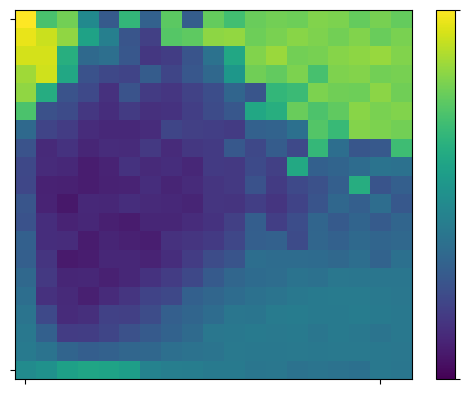

In [13]:
plt.figure()
img = plt.imshow(im, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(img)
cbar.set_ticks([vmin, vmax])             
cbar.set_ticklabels([])             
plt.xticks([0, len(alpha_values) - 2], ["{:.2f}".format(alpha_values[1]), 1])
plt.yticks([0, len(g_values) - 1], [0, "{:.1f}".format(g_values[-1])])
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.gca().invert_yaxis()

plt.savefig('lyap_pendulum_partial_information_median.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()


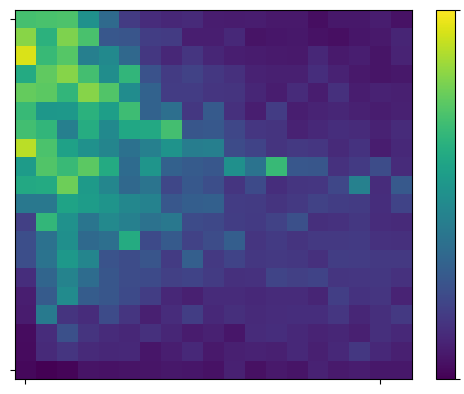

In [14]:

im = np.log10(res_full_information_median[:, 1:, 1])
plt.figure()
img = plt.imshow(im, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(img)
cbar.set_ticks([vmin, vmax])             
cbar.set_ticklabels([])             
plt.xticks([0, len(alpha_values) - 2], ["{:.2f}".format(alpha_values[0]), 1])
plt.gca().set_xticklabels([])
plt.yticks([0, len(g_values) - 1], ["{:.2f}".format(vmin), "{:.2f}".format(vmax)])
plt.gca().set_yticklabels([])
plt.gca().invert_yaxis()

plt.savefig('lyap_pendulum_full_information_median.png', bbox_inches='tight', dpi=300, transparent=True)
# svg
plt.savefig('lyap_pendulum_full_information_median.svg', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

In [15]:

# Plot 4: Lyapunov exponents with inset
im = np.log10(res_full_information_median[:, 1:, 1])


In [16]:
def bootstrap_ci(data, n_bootstraps=10000):
    bootstrap_samples = np.random.choice(data, size=(n_bootstraps, len(data)), replace=True)
    bootstrap_medians = np.median(bootstrap_samples, axis=1)
    return np.percentile(bootstrap_medians, [2.5, 97.5])



In [17]:
lyapunov = np.load('/Users/iliasoroka/esn_final/lyap_exps_pendulum_dt_0.1.npy', allow_pickle=True)

In [18]:
lyapunov.shape

(30, 20)

In [19]:
cis = []
for i in range(lyapunov.shape[1]):
    bootstrapped_ci = bootstrap_ci(lyapunov[:,i])
    cis.append(bootstrapped_ci)
cis = np.array(cis)
cis.shape
cis


array([[ 5.64048835e-02,  7.11038820e-02],
       [ 2.80958397e-04,  4.22496861e-03],
       [-7.41257519e-02, -5.69780474e-02],
       [-3.00671853e-01, -2.14505721e-01],
       [-1.08303934e+00, -1.01822552e+00],
       [-1.23746398e+00, -1.19579592e+00],
       [-1.29380584e+00, -1.27009502e+00],
       [-1.33225062e+00, -1.30571878e+00],
       [-1.35645023e+00, -1.33428282e+00],
       [-1.37696052e+00, -1.35225472e+00],
       [-1.39277017e+00, -1.38057813e+00],
       [-1.40875542e+00, -1.38869736e+00],
       [-1.42153391e+00, -1.40025508e+00],
       [-1.43338540e+00, -1.41404986e+00],
       [-1.44138467e+00, -1.42595962e+00],
       [-1.44952229e+00, -1.43103039e+00],
       [-1.46035925e+00, -1.44518515e+00],
       [-1.46733150e+00, -1.45585340e+00],
       [-1.47494945e+00, -1.45982430e+00],
       [-1.48250464e+00, -1.46743178e+00]])

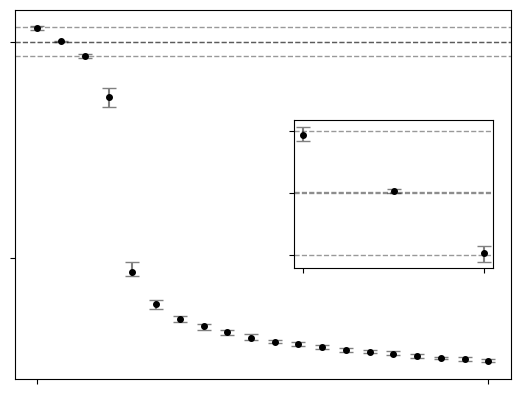

In [20]:
plt.figure()
all_lyapunov = lyapunov
median_lyapunov = np.median(lyapunov, axis=0)

ci_lower = cis[:, 0]
ci_upper = cis[:, 1]
yerr = np.array([median_lyapunov - ci_lower, ci_upper - median_lyapunov])

img = plt.errorbar(range(1, len(median_lyapunov) + 1), median_lyapunov,
             yerr=yerr, fmt='k.', ms=8, capsize=5, 
             ecolor='gray')

plt.xticks([1, len(median_lyapunov)], ['', ''])
plt.yticks([0, -1], ['', ''])
plt.minorticks_off()
real_lyapunov = [0.06679198 , 0.00059611, -0.00055851, -0.06684586]
for idx, lyap_val in enumerate(real_lyapunov):
    plt.axhline(y=lyap_val, color='k', linestyle='--', 
                linewidth=1, alpha=0.4)

axins = inset_axes(plt.gca(), width="40%", height="40%", loc='center right')
yerr_inset = np.array([median_lyapunov[:3] - ci_lower[:3], ci_upper[:3] - median_lyapunov[:3]])
axins.errorbar(range(1, 4), median_lyapunov[:3], yerr=yerr_inset, 
               fmt='k.', ms=8, capsize=5, ecolor='gray')
for idx, lyap_val in enumerate(real_lyapunov):
    axins.axhline(y=lyap_val, color='k', linestyle='--', 
                  linewidth=1, alpha=0.4)
axins.set_xticks([1, 3], ['', ''])
axins.set_yticklabels([])
axins.tick_params(labelsize=18)
axins.set_yticks([-0.06679412, 0, 0.06684598])
axins.minorticks_off()

plt.savefig('pdf_pendulum_lyapunov_exponents.png', bbox_inches='tight', dpi=700, transparent=True)
plt.show()